In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('./Dataset/Dataset1.csv')

## ANN Model Comparison: Good Generalization vs Overfitting
We will build two ANN models:
- **Model 1:** Well-regularized, generalizes well (good accuracy on both train and test)
- **Model 2:** Overfits (very high train accuracy, poor test accuracy)

We will use the features to predict the crop label (classification).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
import numpy as np

# Prepare features and target
X = df.drop('label', axis=1).values
le = LabelEncoder()
y = le.fit_transform(df['label'])
y_cat = to_categorical(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

num_classes = y_cat.shape[1]

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Model 1: Well-regularized ANN
model1 = Sequential()
model1.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model1.add(Dropout(0.3))
model1.add(Dense(32, activation='relu'))
model1.add(Dropout(0.3))
model1.add(Dense(num_classes, activation='softmax'))

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history1 = model1.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1290 - loss: 2.9190 - val_accuracy: 0.4318 - val_loss: 2.6383
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1290 - loss: 2.9190 - val_accuracy: 0.4318 - val_loss: 2.6383
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2818 - loss: 2.5133 - val_accuracy: 0.5773 - val_loss: 2.1455
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2818 - loss: 2.5133 - val_accuracy: 0.5773 - val_loss: 2.1455
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4051 - loss: 2.0639 - val_accuracy: 0.6682 - val_loss: 1.5857
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4051 - loss: 2.0639 - val_accuracy: 0.6682 - val_loss: 1.5857
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5114 - loss: 1.6153 - val_accuracy: 0.7568 - val_loss: 1.1386
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5114 - loss: 1.6153 - val_accuracy: 0.7568 - val_l

In [7]:
# Model 2: Overfitting ANN (no dropout, more parameters, more epochs)
model2 = Sequential()
model2.add(Dense(256, activation='relu', input_dim=X_train.shape[1]))
model2.add(Dense(128, activation='relu'))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(num_classes, activation='softmax'))

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_train, y_train, epochs=200, batch_size=8, validation_data=(X_test, y_test), verbose=1)

Epoch 1/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7023 - loss: 1.1904 - val_accuracy: 0.9227 - val_loss: 0.2707
Epoch 2/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7023 - loss: 1.1904 - val_accuracy: 0.9227 - val_loss: 0.2707
Epoch 2/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9267 - loss: 0.2167 - val_accuracy: 0.9409 - val_loss: 0.1592
Epoch 3/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9267 - loss: 0.2167 - val_accuracy: 0.9409 - val_loss: 0.1592
Epoch 3/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9403 - loss: 0.1404 - val_accuracy: 0.9636 - val_loss: 0.0923
Epoch 4/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9403 - loss: 0.1404 - val_accuracy: 0.9636 - val_loss: 0.0923
Epoch 4/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9540 - loss: 0.1168 - val_accuracy: 0.9250 - val_loss: 0.1743
Epoch 5/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9540 - loss: 0.1168 - va

In [8]:
# Evaluate both models
train_acc1 = model1.evaluate(X_train, y_train, verbose=0)[1]
test_acc1 = model1.evaluate(X_test, y_test, verbose=0)[1]
train_acc2 = model2.evaluate(X_train, y_train, verbose=0)[1]
test_acc2 = model2.evaluate(X_test, y_test, verbose=0)[1]

print(f"Model 1 (Well-regularized) - Train Accuracy: {train_acc1:.3f}, Test Accuracy: {test_acc1:.3f}")
print(f"Model 2 (Overfitting) - Train Accuracy: {train_acc2:.3f}, Test Accuracy: {test_acc2:.3f}")

Model 1 (Well-regularized) - Train Accuracy: 0.972, Test Accuracy: 0.975
Model 2 (Overfitting) - Train Accuracy: 1.000, Test Accuracy: 0.991


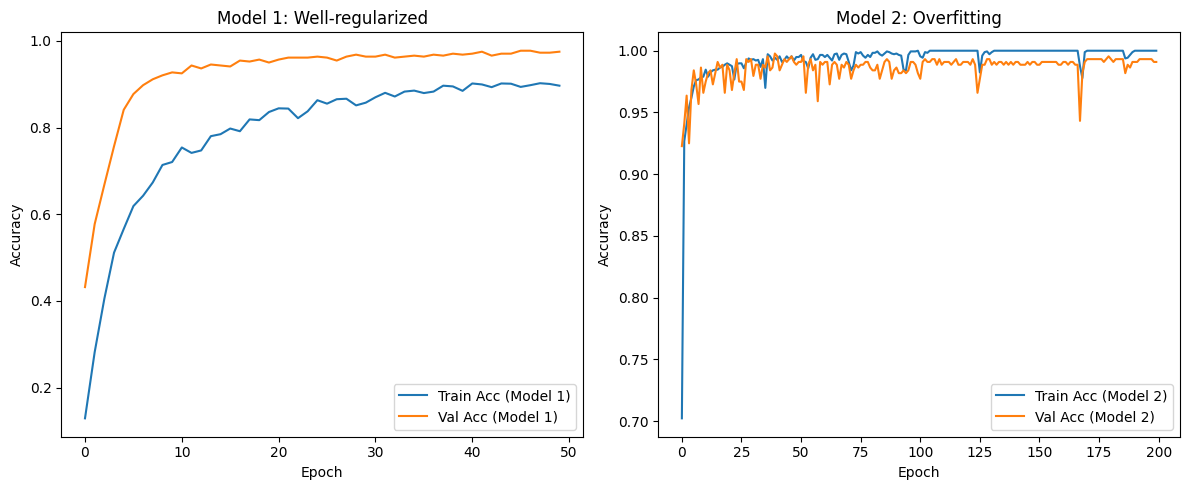

In [9]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy for both models
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history1.history['accuracy'], label='Train Acc (Model 1)')
plt.plot(history1.history['val_accuracy'], label='Val Acc (Model 1)')
plt.title('Model 1: Well-regularized')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history2.history['accuracy'], label='Train Acc (Model 2)')
plt.plot(history2.history['val_accuracy'], label='Val Acc (Model 2)')
plt.title('Model 2: Overfitting')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()